# H3 — Le basculement (dissociation / *shifting bias*)

**Hypothèse centrale du mémoire.** Cadre : Bai et al. (2024, arXiv:2402.04105) pour le comparatif/IAT, Gallegos et al. (2025) pour le single.

- En **single** (un CV, accepter / rejeter), le modèle tend à **favoriser la minorité** — sur-correction RLHF / désirabilité sociale.
- En **comparatif** (deux CV, choix forcé), il tend à **favoriser la majorité** — les stéréotypes implicites s'activent.

Le *basculement* est le passage de l'un à l'autre.

**Métriques** (centrées sur 0 ; **positif = favorise la minorité**, **négatif = favorise la majorité**) :
- Single : `fav_single = P(accepter | minorité) − P(accepter | français)`  ∈ [−1, 1]
- Comparatif : `fav_comp = 0,5 − P(français choisi)`  ∈ [−0,5, 0,5]

> **Choix de conception** : les deux métriques ne sont **pas** sur la même échelle (acceptation absolue vs choix relatif). On les garde donc **séparées**, chacune sur son axe propre — **pas de pente reliant les deux points**. Chaque figure a deux panneaux (single | comparatif), échelles Y indépendantes et symétriques autour de 0.

In [1]:
import sys
sys.path.insert(0, '..')
from utils.analysis import *
set_style()

df = charger_behavioral()
single = df[df.eval_mode == 'single'].copy()
comp = df[df.eval_mode == 'comparative'].dropna(subset=['chose_majorite']).copy()
MODELES = modeles_tries(df)
MODS_C = [m for m in MODELES if m in comp.model.unique()]
print(f"{len(MODELES)} modèles · comparatif disponible pour {len(MODS_C)} : {MODS_C}")

6 modèles · comparatif disponible pour 6 : ['Mistral-Nemo-Novita', 'Qwen3.6-27B-FP8', 'Gemma-4-31B-it', 'Qwen3.7-max-Novita', 'DeepSeek-Flash', 'DeepSeek-Pro']


## Tableau récapitulatif des favoritismes

Pour chaque modèle × minorité : favoritisme single, favoritisme comparatif, et Δ basculement = `fav_comp − fav_single` (négatif = bascule vers la majorité en comparatif).

In [2]:
rows = []
for m in MODELES:
    for eth in MIN:
        fs = fav_single(single, m, eth)
        fc = fav_comp(comp, m, eth)
        rows.append((m, ETIQ_ETH[eth], round(fs, 3), round(fc, 3),
                     round(fc - fs, 3) if not (np.isnan(fs) or np.isnan(fc)) else np.nan))
recap = pd.DataFrame(rows, columns=['modèle', 'minorité', 'fav_single', 'fav_comp', 'Δ basculement'])
display(recap)

n_valid = recap['Δ basculement'].notna().sum()
n_down = (recap['Δ basculement'] < 0).sum()
print(f"{n_down}/{n_valid} cas (modèle×minorité) basculent vers la majorité (Δ<0) en comparatif.")

,modèle,minorité,fav_single,fav_comp,Δ basculement
0,Mistral-Nemo-Novita,Maghrébin,0.026,0.065,0.038
1,Mistral-Nemo-Novita,Africain,0.018,0.066,0.048
2,Qwen3.6-27B-FP8,Maghrébin,-0.030,0.000,0.030
3,Qwen3.6-27B-FP8,Africain,0.020,0.003,-0.018
4,Gemma-4-31B-it,Maghrébin,-0.010,0.000,0.010
5,Gemma-4-31B-it,Africain,-0.020,0.000,0.020
6,Qwen3.7-max-Novita,Maghrébin,0.010,0.005,-0.005
7,Qwen3.7-max-Novita,Africain,0.010,0.000,-0.010
8,DeepSeek-Flash,Maghrébin,0.046,-0.003,-0.049
9,DeepSeek-Flash,Africain,0.005,0.003,-0.003


6/12 cas (modèle×minorité) basculent vers la majorité (Δ<0) en comparatif.


### Variante 1 — Deux panneaux, x = modèles, couleur = minorité

Vue inter-modèles : pour chaque mode, on lit d'un coup quels modèles favorisent la minorité (au-dessus de 0) ou la majorité (en dessous). Les deux panneaux ont leur propre échelle Y.

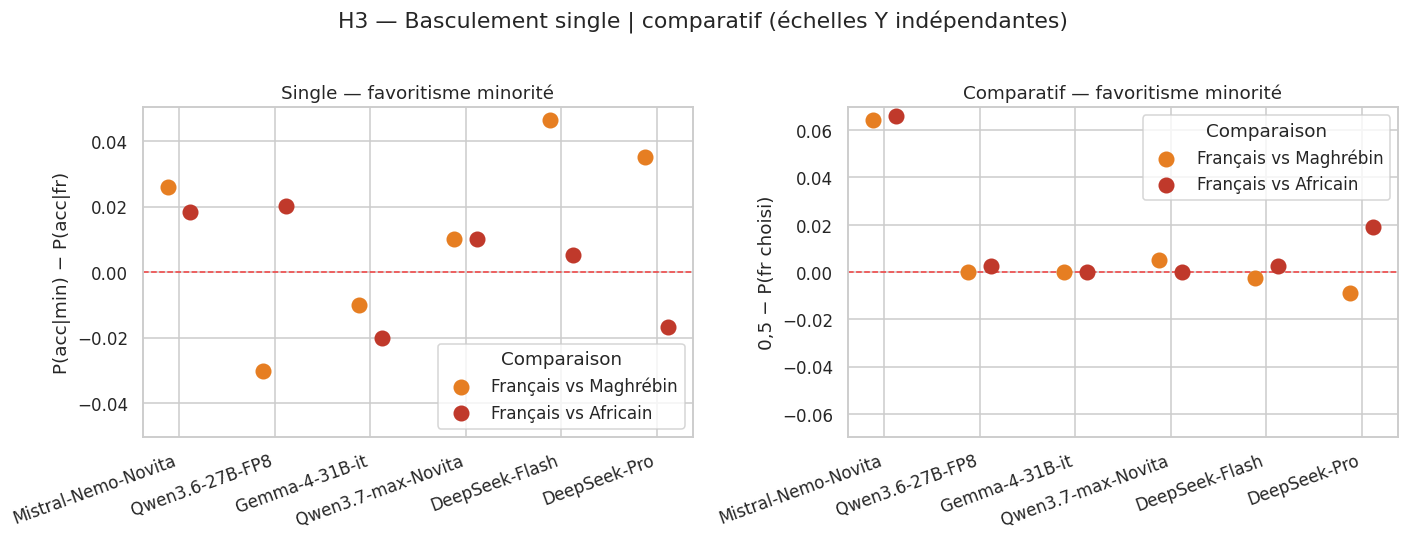

In [3]:
# Étiquettes de comparaison (ancrées sur le français), mêmes couleurs que COUL_ETH
PAIR_LABEL = {'maghrebin': 'Français vs Maghrébin', 'african': 'Français vs Africain'}

fig, (axS, axC) = plt.subplots(1, 2, figsize=(13, 4.8))
xpos = np.arange(len(MODELES)); off = {'maghrebin': -0.12, 'african': 0.12}

for eth in MIN:
    ysS = [fav_single(single, m, eth) for m in MODELES]
    axS.scatter(xpos + off[eth], ysS, s=90, color=COUL_ETH[eth], label=PAIR_LABEL[eth], zorder=3)
axS.axhline(0, c='red', ls='--', lw=1, alpha=.7)
axS.set_xticks(xpos); axS.set_xticklabels(MODELES, rotation=20, ha='right')
axS.set_title('Single — favoritisme minorité'); axS.set_ylabel('P(acc|min) − P(acc|fr)')
yl = max(0.05, np.nanmax(np.abs(axS.get_ylim()))); axS.set_ylim(-yl, yl); axS.legend(title='Comparaison')

xc = np.arange(len(MODS_C))
for eth in MIN:
    ysC = [fav_comp(comp, m, eth) for m in MODS_C]
    axC.scatter(xc + off[eth], ysC, s=90, color=COUL_ETH[eth], label=PAIR_LABEL[eth], zorder=3)
axC.axhline(0, c='red', ls='--', lw=1, alpha=.7)
axC.set_xticks(xc); axC.set_xticklabels(MODS_C, rotation=20, ha='right')
axC.set_title('Comparatif — favoritisme minorité'); axC.set_ylabel('0,5 − P(fr choisi)')
yl = max(0.05, np.nanmax(np.abs(axC.get_ylim()))); axC.set_ylim(-yl, yl); axC.legend(title='Comparaison')

fig.suptitle('H3 — Basculement single | comparatif (échelles Y indépendantes)', y=1.02)
plt.tight_layout(); plt.show()

### Variante 2 — Deux panneaux, x = minorité, couleur = modèle

Met l'accent sur la différence entre minorités (maghrébin vs africain) plutôt qu'entre modèles. Une couleur par modèle, reliée pour suivre chaque modèle d'une minorité à l'autre.

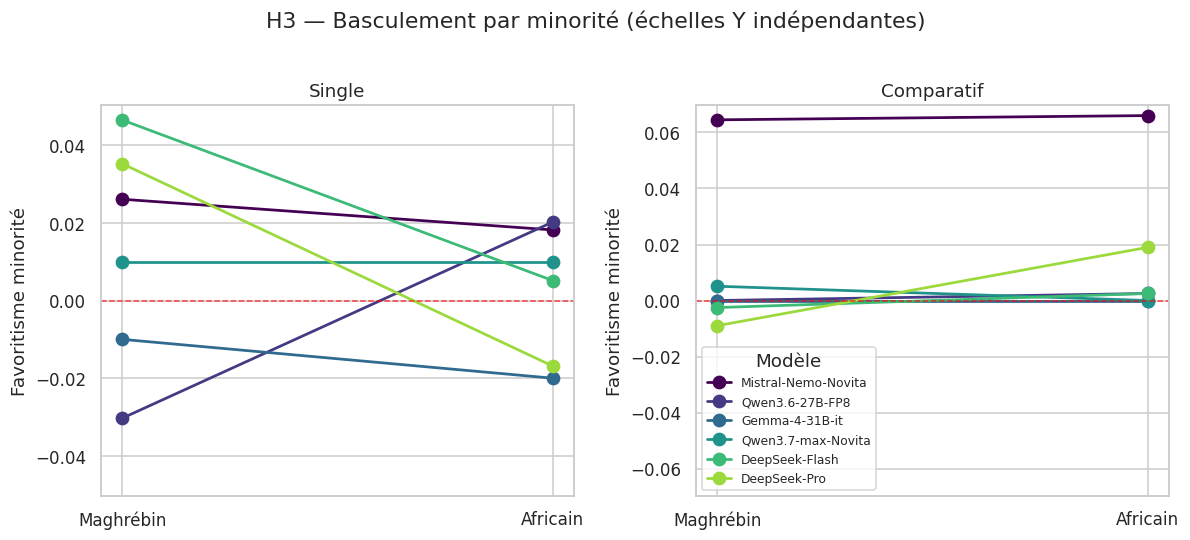

In [4]:
cmap = plt.cm.viridis(np.linspace(0, 0.85, len(MODELES)))
coul_mod = dict(zip(MODELES, cmap))
fig, (axS, axC) = plt.subplots(1, 2, figsize=(11, 4.8))
xe = np.arange(len(MIN))

for m in MODELES:
    axS.plot(xe, [fav_single(single, m, e) for e in MIN], '-o', color=coul_mod[m], label=m, lw=1.8, ms=8)
axS.axhline(0, c='red', ls='--', lw=1, alpha=.7)
axS.set_xticks(xe); axS.set_xticklabels([ETIQ_ETH[e] for e in MIN])
axS.set_title('Single'); axS.set_ylabel('Favoritisme minorité')
yl = max(0.05, np.nanmax(np.abs(axS.get_ylim()))); axS.set_ylim(-yl, yl)

for m in MODS_C:
    axC.plot(xe, [fav_comp(comp, m, e) for e in MIN], '-o', color=coul_mod[m], label=m, lw=1.8, ms=8)
axC.axhline(0, c='red', ls='--', lw=1, alpha=.7)
axC.set_xticks(xe); axC.set_xticklabels([ETIQ_ETH[e] for e in MIN])
axC.set_title('Comparatif'); axC.set_ylabel('Favoritisme minorité')
yl = max(0.05, np.nanmax(np.abs(axC.get_ylim()))); axC.set_ylim(-yl, yl)
axC.legend(title='Modèle', fontsize=8, loc='best')

fig.suptitle('H3 — Basculement par minorité (échelles Y indépendantes)', y=1.02)
plt.tight_layout(); plt.show()

### Variante 3 — Barres divergentes horizontales

Lecture immédiate du **signe** et de l'**ampleur** : barre vers la droite = pro-minorité, vers la gauche = pro-majorité. Une barre par modèle×minorité, un panneau par mode.

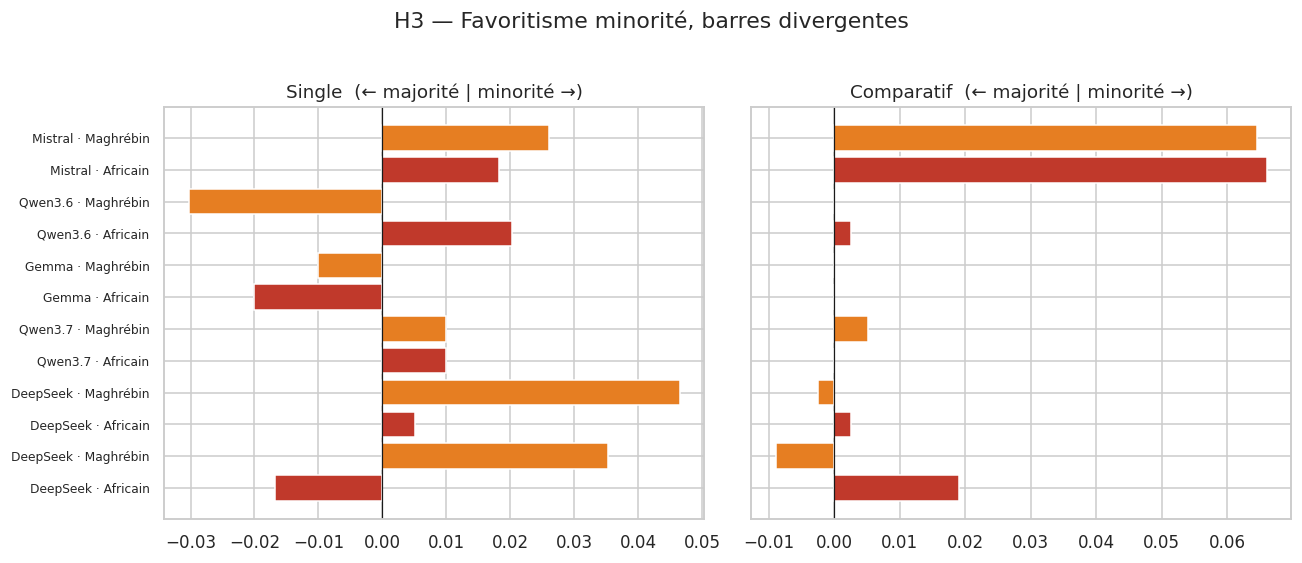

In [5]:
labels = [f"{m.split('-')[0]} · {ETIQ_ETH[e]}" for m in MODELES for e in MIN]
yb = np.arange(len(labels))[::-1]
cols = [COUL_ETH[e] for m in MODELES for e in MIN]

valsS = [fav_single(single, m, e) for m in MODELES for e in MIN]
valsC = [fav_comp(comp, m, e) for m in MODELES for e in MIN]

fig, (axS, axC) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axS.barh(yb, valsS, color=cols); axS.axvline(0, c='k', lw=.8)
axS.set_yticks(yb); axS.set_yticklabels(labels, fontsize=8)
axS.set_title('Single  (← majorité | minorité →)')
axC.barh(yb, valsC, color=cols); axC.axvline(0, c='k', lw=.8)
axC.set_title('Comparatif  (← majorité | minorité →)')

fig.suptitle('H3 — Favoritisme minorité, barres divergentes', y=1.02)
plt.tight_layout(); plt.show()